### EN3160 Assignment 01: Intensity Transformations and Neighborhood Filtering
#### Bandara W.D.A.C. - 230082G

In [1]:
# imports
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
import cv2 as cv

##### Q1. Intensity tranformation on 'emma' 

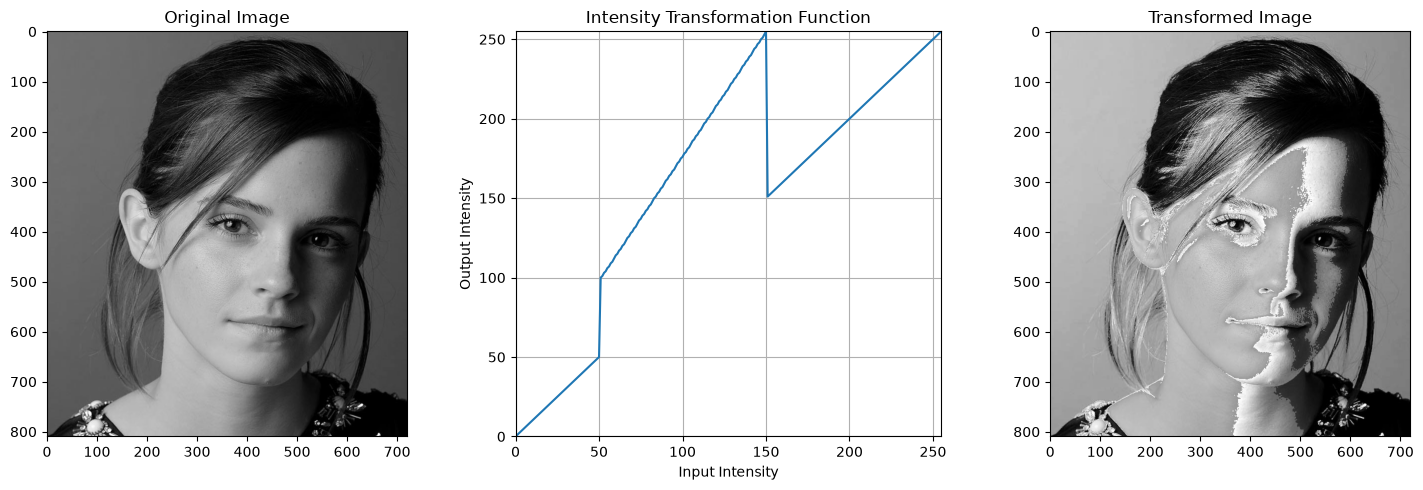

In [2]:
img_emma = cv.imread('./images/emma.jpeg', cv.IMREAD_GRAYSCALE)
assert img_emma is not None

def intensity_transform(im, breakpoints):
    tf = np.zeros(256, dtype=np.uint8)
    for i in range(len(breakpoints) - 1):
        x_start, y_start = breakpoints[i]
        x_end, y_end = breakpoints[i + 1]
        x = np.arange(x_start, x_end + 1)
        tf[x] = np.linspace(y_start, y_end, num=len(x)).astype('uint8')
    return cv.LUT(im, tf), tf

bp = np.array([(0, 0), (50, 50), (51, 100), (150, 255), (151, 151), (255, 255)])

img_transformed, tf = intensity_transform(img_emma, bp)

fig, ax = plt.subplots(1, 3, figsize=(15, 5))
ax[0].imshow(img_emma, cmap='gray')
ax[0].set_title('Original Image')
ax[1].plot(tf)
ax[1].set_title('Intensity Transformation Function')
ax[1].set_xlabel('Input Intensity')
ax[1].set_ylabel('Output Intensity')
ax[1].set_xlim([0, 255])
ax[1].set_ylim([0, 255])
ax[1].grid()
ax[2].imshow(img_transformed, cmap='gray')
ax[2].set_title('Transformed Image')
plt.tight_layout()
plt.show()

According to the plot and images above, a certain range of intensities has been brightened. Also the discontinuities in the transformation funtion create sudden intensity jumps. 

We can adjust the transformation function to achieve much more visually pleasing results as follows.

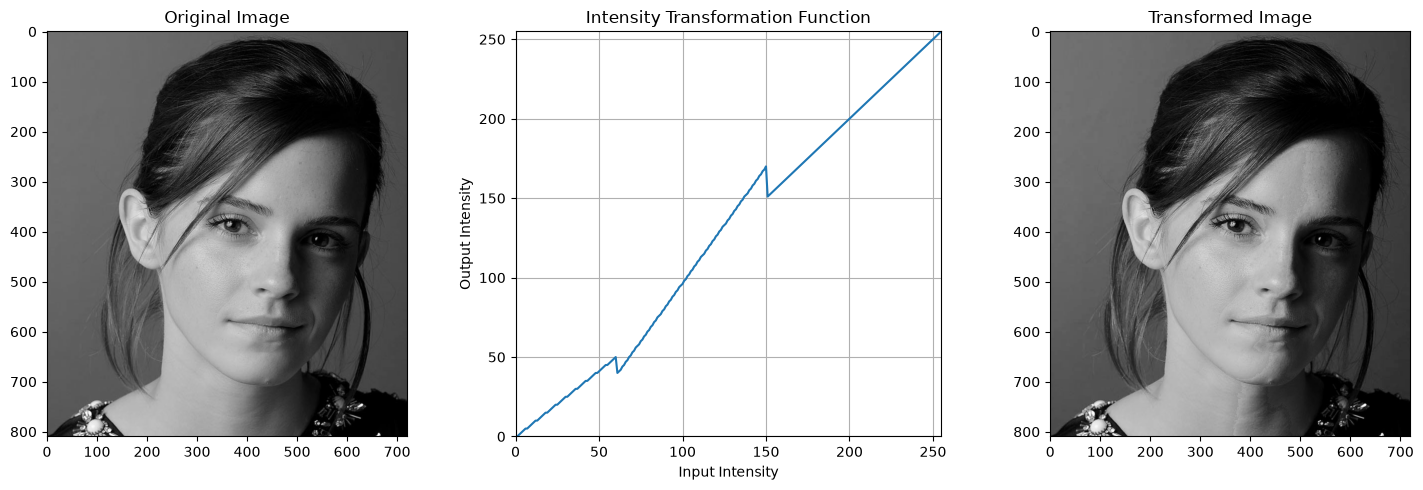

In [3]:
bp = np.array([(0, 0), (60, 50), (61, 40), (150, 170), (151, 151), (255, 255)])

img_transformed, tf = intensity_transform(img_emma, bp)

fig, ax = plt.subplots(1, 3, figsize=(15, 5))
ax[0].imshow(img_emma, cmap='gray')
ax[0].set_title('Original Image')
ax[1].plot(tf)
ax[1].set_title('Intensity Transformation Function')
ax[1].set_xlabel('Input Intensity')
ax[1].set_ylabel('Output Intensity')
ax[1].set_xlim([0, 255])
ax[1].set_ylim([0, 255])
ax[1].grid()
ax[2].imshow(img_transformed, cmap='gray')
ax[2].set_title('Transformed Image')
plt.tight_layout()
plt.show()

##### Q2. Intensity tranformations on 'brain' 

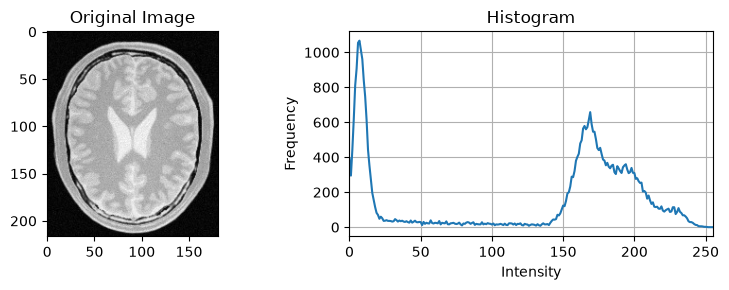

In [4]:
img_brain = cv.imread("./images/brain.jpeg", cv.IMREAD_GRAYSCALE)
assert img_brain is not None

hist = cv.calcHist([img_brain], [0], None, [256], [0, 256])

fig, ax = plt.subplots(1, 2, figsize=(8, 3))
ax[0].imshow(img_brain, cmap='gray')
ax[0].set_title('Original Image')
ax[1].plot(hist)
ax[1].set_title('Histogram')
ax[1].set_xlabel('Intensity')
ax[1].set_ylabel('Frequency')
ax[1].set_xlim([0, 255])
ax[1].grid()
plt.tight_layout()
plt.show()

According to the intensity histogram, white matter has intensities greater than ~180 and gray matter intensity region spans from ~140-180.

**Extracting white matter**

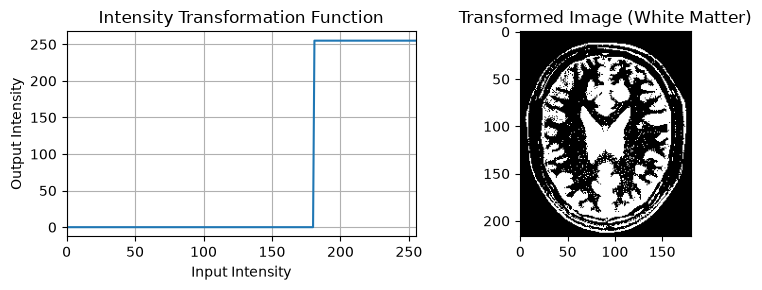

In [5]:
bp = np.array([(0, 0), (180, 0), (181, 255), (255, 255)])

white_matter, tf = intensity_transform(img_brain, bp)

fig, ax = plt.subplots(1, 2, figsize=(8, 3))
ax[0].plot(tf)
ax[0].set_title('Intensity Transformation Function')
ax[0].set_xlabel('Input Intensity')
ax[0].set_ylabel('Output Intensity')
ax[0].set_xlim([0, 255])
ax[0].grid()
ax[1].imshow(white_matter, cmap='gray')
ax[1].set_title('Transformed Image (White Matter)')
plt.tight_layout()
plt.show()

**Extracting gray matter**

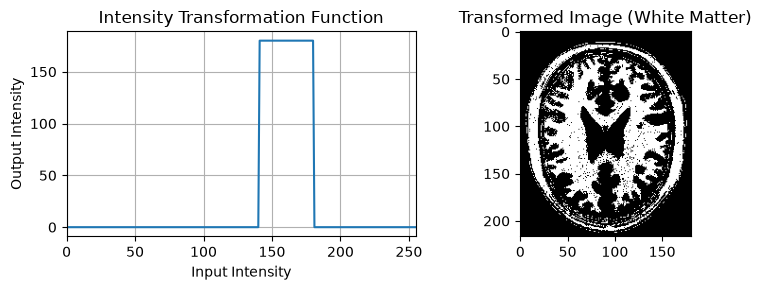

In [6]:
bp = np.array([(0, 0), (140, 0), (141, 180), (180, 180), (181, 0), (255, 0)])

white_matter, tf = intensity_transform(img_brain, bp)

fig, ax = plt.subplots(1, 2, figsize=(8, 3))
ax[0].plot(tf)
ax[0].set_title('Intensity Transformation Function')
ax[0].set_xlabel('Input Intensity')
ax[0].set_ylabel('Output Intensity')
ax[0].set_xlim([0, 255])
ax[0].grid()
ax[1].imshow(white_matter, cmap='gray')
ax[1].set_title('Transformed Image (White Matter)')
plt.tight_layout()
plt.show()

##### Q3. Gamma correction

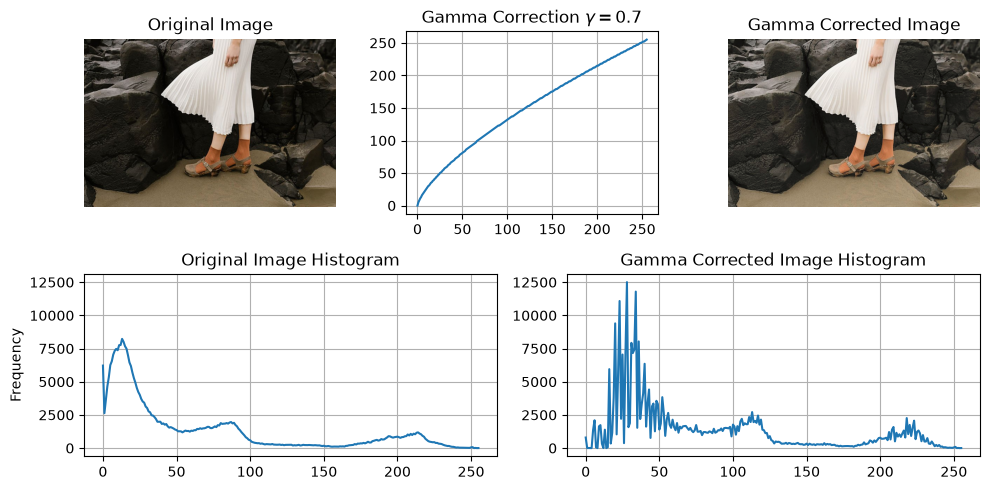

In [ ]:
img_beach = cv.imread("./images/beach.jpeg", cv.IMREAD_COLOR)
assert img_beach is not None

img_lab = cv.cvtColor(img_beach, cv.COLOR_BGR2LAB)

gamma = 0.7
t = np.array([((i / 255.0) ** gamma) * 255 for i in np.arange(0, 256)]).astype("uint8")
img_lab[:, :, 0] = cv.LUT(img_lab[:, :, 0], t)
img_corrected = cv.cvtColor(img_lab, cv.COLOR_LAB2BGR)

hist_original = cv.calcHist([img_beach], [0], None, [256], [0, 256])
hist_gamma_corrected = cv.calcHist([img_corrected], [0], None, [256], [0, 256])

fig = plt.figure(figsize=(10, 5))
gs = fig.add_gridspec(2, 6)
ax1 = fig.add_subplot(gs[0, 0:2])
ax2 = fig.add_subplot(gs[0, 2:4])
ax3 = fig.add_subplot(gs[0, 4:6])
ax4 = fig.add_subplot(gs[1, 0:3])
ax5 = fig.add_subplot(gs[1, 3:6], sharey=ax4)

ax1.imshow(cv.cvtColor(img_beach, cv.COLOR_BGR2RGB))
ax1.set_title("Original Image")
ax1.axis("off")
ax2.plot(t)
ax2.set_title(r"Gamma Correction $\gamma = 0.7$")
ax3.imshow(cv.cvtColor(img_corrected, cv.COLOR_BGR2RGB))
ax3.set_title("Gamma Corrected Image")
ax3.axis("off")
ax4.plot(hist_original)
ax4.set_title("Original Image Histogram")
ax5.plot(hist_gamma_corrected)
ax5.set_title("Gamma Corrected Image Histogram")
ax4.set_ylabel("Frequency")
for ax in [ax2, ax4, ax5]:
    ax.grid()
plt.tight_layout()
plt.show()

Dark regions have been brightened to enhance shadows.

##### Q4. Increasing the vibrance

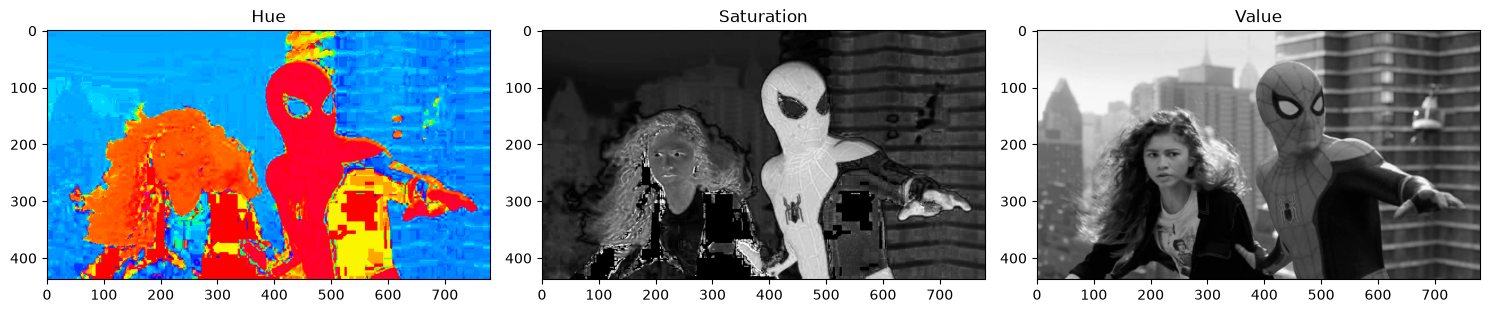

In [42]:
img_spidey = cv.imread("./images/spidey.jpeg", cv.IMREAD_COLOR)
assert img_spidey is not None

h, s, v = cv.split(cv.cvtColor(img_spidey, cv.COLOR_BGR2HSV))

fig, ax = plt.subplots(1, 3, figsize=(15, 5))
ax[0].imshow(h, cmap='hsv')
ax[1].imshow(s, cmap='gray')
ax[2].imshow(v, cmap='gray')
ax[0].set_title('Hue')
ax[1].set_title('Saturation')
ax[2].set_title('Value')
plt.tight_layout()
plt.show()

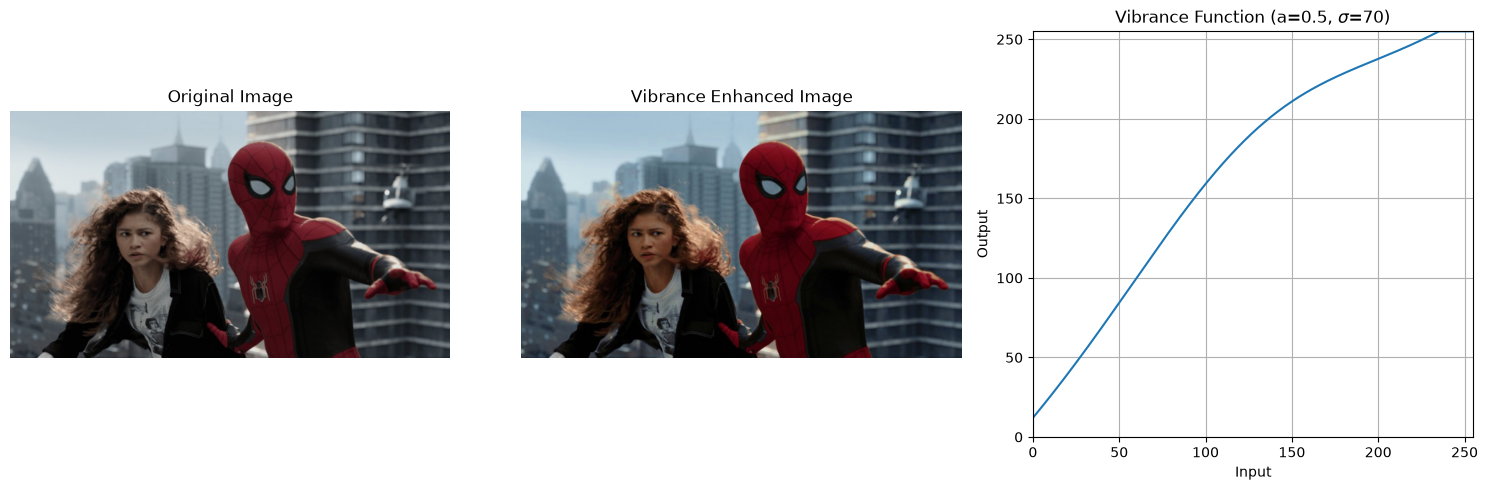

In [71]:
def f(x, a, sigma):
    return np.minimum(x + a * 128 * np.exp( -1 * ((x - 128) ** 2) / (2 * (sigma ** 2))), 255)

a = 0.5; sigma = 70

processed_s = f(s.astype(np.float32), a, sigma).astype(np.uint8)
hsv_corrected = cv.merge([h, processed_s, v])

fig, ax = plt.subplots(1, 3, figsize=(15, 5))
ax[0].imshow(cv.cvtColor(img_spidey, cv.COLOR_BGR2RGB))
ax[0].set_title('Original Image')
ax[1].imshow(cv.cvtColor(hsv_corrected, cv.COLOR_HSV2RGB))
ax[1].set_title('Vibrance Enhanced Image')
ax[2].plot(f(np.arange(256), a, sigma))
ax[2].set_title(fr'Vibrance Function (a={a}, $\sigma$={sigma})')
ax[2].set_xlabel('Input')
ax[2].set_ylabel('Output')
ax[2].set_xlim([0, 255])
ax[2].set_ylim([0, 255])
ax[2].grid()
for a in [ax[0], ax[1]]:
    a.axis('off')
plt.tight_layout()
plt.show()